In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("datafile (1).csv")

In [5]:
print(df.head())

    Crop           State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR   Uttar Pradesh                                9794.05   
1  ARHAR       Karnataka                               10593.15   
2  ARHAR         Gujarat                               13468.82   
3  ARHAR  Andhra Pradesh                               17051.66   
4  ARHAR     Maharashtra                               17130.55   

   Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  \
0                            23076.74                            1941.55   
1                            16528.68                            2172.46   
2                            19551.90                            1898.30   
3                            24171.65                            3670.54   
4                            25270.26                            2775.80   

   Yield (Quintal/ Hectare)   
0                       9.83  
1                       7.47  
2                       9.59  
3               

In [6]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     object 
 1   State                                  49 non-null     object 
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB
None
       Cost of Cultivation (`/Hectare) A2+FL  \
count                              49.000000   
mean                            20363.537347   
std                             13561.435306   
min                              5483.540000   
25%                             12774.410000   
50%      

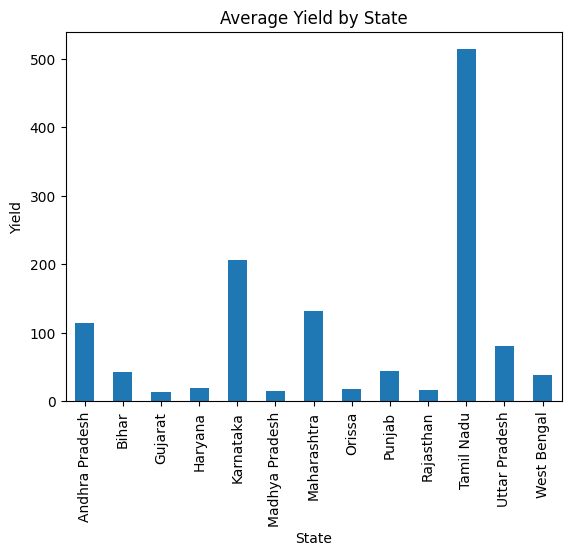

In [7]:
import matplotlib.pyplot as plt

df.groupby("State")["Yield (Quintal/ Hectare) "].mean().plot(kind="bar")

plt.title("Average Yield by State")
plt.ylabel("Yield")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[["Cost of Cultivation (`/Hectare) C2"]]

# Target
y = df["Yield (Quintal/ Hectare) "]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print(predictions[:5])

[-44.31873538  -5.70894806  89.66991881 668.47454778  74.37888584]


In [9]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("Accuracy:", score)

Accuracy: 0.7707780307656265


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("datafile (2).csv")

In [4]:
print(df.head())

  Crop               Production 2006-07  Production 2007-08  \
0  Total Foodgrains               158.8               168.6   
1              Rice               200.8               207.9   
2             Wheat               131.6               136.4   
3             Jowar               124.3               137.8   
4             Bajra               136.4               161.5   

   Production 2008-09  Production 2009-10  Production 2010-11  Area 2006-07  \
0               171.3               159.4               178.9         128.5   
1               213.3               191.6               206.4         168.5   
2               140.1               140.3               150.8         115.0   
3               126.0               116.5               121.8         120.7   
4               143.9               105.4               167.9          94.5   

   Area 2007-08  Area 2008-09  Area 2009-10  Area 2010-11  Yield 2006-07  \
0         128.8         127.6         126.0         131.7          123

In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                55 non-null     object 
 1   Production 2006-07  55 non-null     float64
 2   Production 2007-08  55 non-null     float64
 3   Production 2008-09  55 non-null     float64
 4   Production 2009-10  55 non-null     float64
 5   Production 2010-11  55 non-null     float64
 6   Area 2006-07        55 non-null     float64
 7   Area 2007-08        55 non-null     float64
 8   Area 2008-09        55 non-null     float64
 9   Area 2009-10        55 non-null     float64
 10  Area 2010-11        55 non-null     float64
 11  Yield 2006-07       55 non-null     float64
 12  Yield 2007-08       55 non-null     float64
 13  Yield 2008-09       55 non-null     float64
 14  Yield 2009-10       55 non-null     float64
 15  Yield 2010-11       55 non-null     float64
dtypes: float64

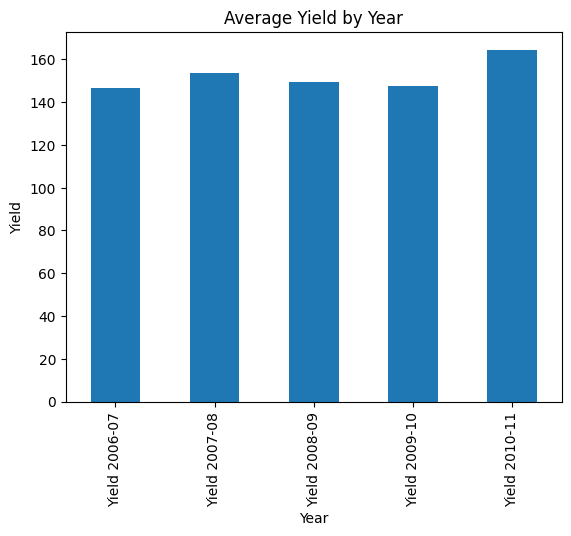

In [8]:
import matplotlib.pyplot as plt

# remove extra spaces
df.columns = df.columns.str.strip()

# select yield columns
yield_data = df[[
    'Yield 2006-07',
    'Yield 2007-08',
    'Yield 2008-09',
    'Yield 2009-10',
    'Yield 2010-11'
]]

# average of each year
avg_yield = yield_data.mean()

# plot
avg_yield.plot(kind='bar')

plt.title("Average Yield by Year")
plt.ylabel("Yield")
plt.xlabel("Year")

plt.show()

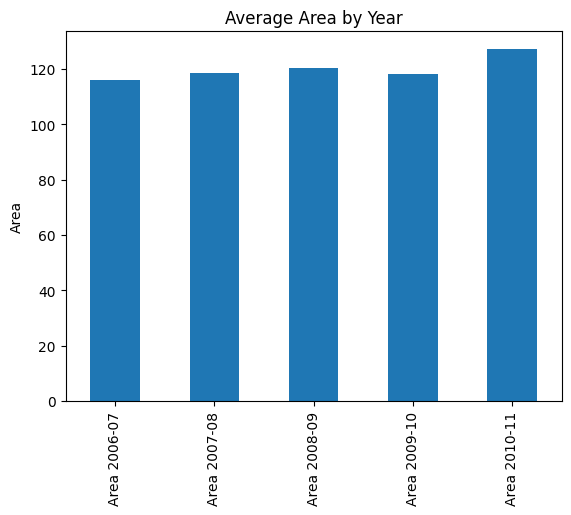

In [9]:
area = df[[
    'Area 2006-07',
    'Area 2007-08',
    'Area 2008-09',
    'Area 2009-10',
    'Area 2010-11'
]]

area.mean().plot(kind='bar')

plt.title("Average Area by Year")
plt.ylabel("Area")
plt.show()

In [10]:
df['Average Yield'] = df[[
    'Yield 2006-07',
    'Yield 2007-08',
    'Yield 2008-09',
    'Yield 2009-10',
    'Yield 2010-11'
]].mean(axis=1)

top_crop = df[['Crop', 'Average Yield']].sort_values(
    by='Average Yield',
    ascending=False
)

print(top_crop.head())

            Crop  Average Yield
38  Total Spices        1212.80
31          Jute         211.24
33  Jute & Mesta         210.32
34     Sannhamp          193.78
40  Dry chilies          191.72
